# Introdução a Clustering

Clustering (agrupamento) é uma tarefa de **aprendizado não supervisionado**: buscamos estruturas nos dados sem utilizar rótulos conhecidos. A ideia é formar grupos cujos elementos sejam semelhantes entre si e diferentes dos elementos dos demais grupos.

Neste notebook veremos três abordagens importantes — **K-Means**, **clustering hierárquico** e **DBSCAN** — além de formas de avaliar os agrupamentos.

## 1. Preparação do ambiente

Usaremos dados sintéticos bidimensionais porque eles permitem visualizar diretamente o comportamento dos algoritmos. Em aplicações reais, a preparação dos dados também pode envolver tratamento de valores ausentes, codificação de variáveis categóricas e redução de dimensionalidade.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.cluster import AgglomerativeClustering, DBSCAN, KMeans
from sklearn.datasets import make_blobs, make_moons
from sklearn.metrics import davies_bouldin_score, silhouette_score
from sklearn.preprocessing import StandardScaler

RANDOM_STATE = 42
plt.style.use("seaborn-v0_8-whitegrid")

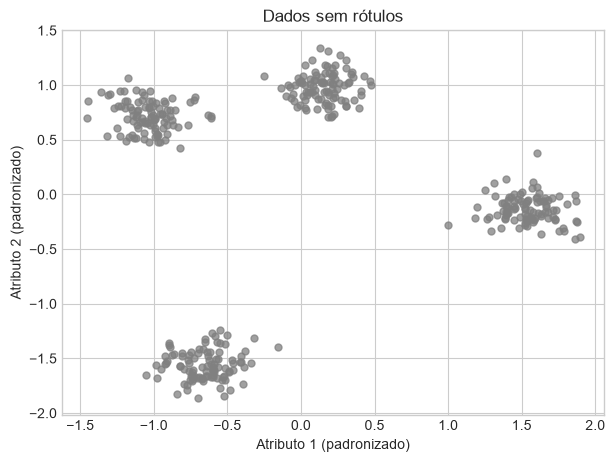

In [2]:
# Criamos quatro grupos aproximadamente esféricos e bem separados.
X_blobs, _ = make_blobs(
    n_samples=400, centers=4, cluster_std=0.85, random_state=RANDOM_STATE
)

# A padronização evita que uma variável com escala maior domine as distâncias.
X_blobs = StandardScaler().fit_transform(X_blobs)

plt.figure(figsize=(7, 5))
plt.scatter(X_blobs[:, 0], X_blobs[:, 1], s=25, color="gray", alpha=0.75)
plt.title("Dados sem rótulos")
plt.xlabel("Atributo 1 (padronizado)")
plt.ylabel("Atributo 2 (padronizado)")
plt.show()

## 2. K-Means

O K-Means representa cada cluster por um **centroide**. Seu funcionamento básico é:

1. escolher $k$ centroides iniciais;
2. associar cada ponto ao centroide mais próximo;
3. recalcular cada centroide pela média dos pontos associados;
4. repetir os passos 2 e 3 até a solução estabilizar.

O algoritmo procura minimizar a soma das distâncias quadráticas dos pontos aos seus centroides, chamada **inércia**. É rápido e fácil de interpretar, mas exige a escolha prévia de $k$, é sensível a outliers e funciona melhor com clusters compactos e aproximadamente esféricos.

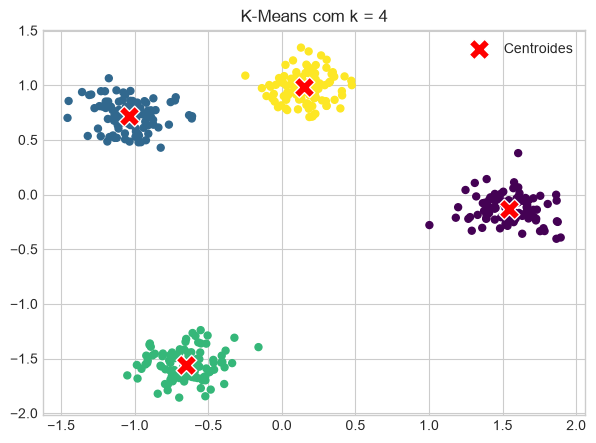

In [3]:
# n_init executa o algoritmo com diferentes inicializações e mantém a melhor.
kmeans = KMeans(n_clusters=4, n_init=10, random_state=RANDOM_STATE)
labels_kmeans = kmeans.fit_predict(X_blobs)

plt.figure(figsize=(7, 5))
plt.scatter(X_blobs[:, 0], X_blobs[:, 1], c=labels_kmeans, cmap="viridis", s=25)
plt.scatter(
    kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1],
    marker="X", s=220, c="red", edgecolor="white", label="Centroides"
)
plt.title("K-Means com k = 4")
plt.legend()
plt.show()

### Como escolher o número de clusters?

No **método do cotovelo**, observamos quando aumentar $k$ deixa de produzir uma redução expressiva da inércia. Já o **coeficiente de silhueta** combina coesão e separação: valores próximos de 1 indicam pontos bem agrupados, próximos de 0 indicam sobreposição e valores negativos sugerem associações inadequadas.

Esses critérios ajudam na decisão, mas não substituem o conhecimento do problema.

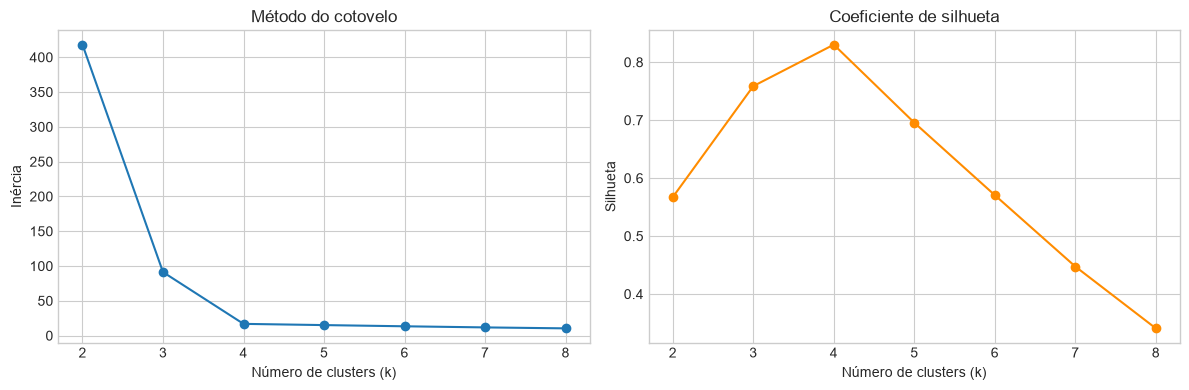

In [4]:
k_values = range(2, 9)
inercias, silhuetas = [], []

for k in k_values:
    modelo = KMeans(n_clusters=k, n_init=10, random_state=RANDOM_STATE)
    rotulos = modelo.fit_predict(X_blobs)
    inercias.append(modelo.inertia_)
    silhuetas.append(silhouette_score(X_blobs, rotulos))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(k_values, inercias, marker="o")
axes[0].set(title="Método do cotovelo", xlabel="Número de clusters (k)", ylabel="Inércia")
axes[1].plot(k_values, silhuetas, marker="o", color="darkorange")
axes[1].set(title="Coeficiente de silhueta", xlabel="Número de clusters (k)", ylabel="Silhueta")
plt.tight_layout()
plt.show()

## 3. Clustering hierárquico aglomerativo

Na abordagem **aglomerativa**, cada ponto começa como um cluster isolado. A cada etapa, os dois grupos mais próximos são unidos até restar a quantidade desejada. O resultado pode ser visualizado em um **dendrograma**, que registra a ordem e a distância das fusões.

O critério de ligação (*linkage*) define como medir a distância entre grupos. O método **Ward**, usado abaixo, escolhe a fusão que causa o menor aumento na variância interna. Um corte horizontal no dendrograma determina os clusters finais.

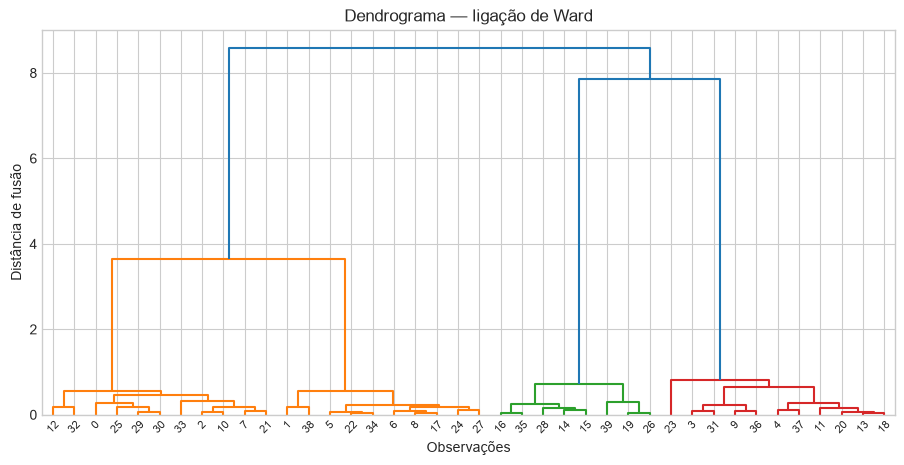

In [5]:
# Uma amostra menor deixa o dendrograma legível durante a apresentação.
X_dendrograma = X_blobs[:40]
matriz_ligacao = linkage(X_dendrograma, method="ward")

plt.figure(figsize=(11, 5))
dendrogram(matriz_ligacao)
plt.title("Dendrograma — ligação de Ward")
plt.xlabel("Observações")
plt.ylabel("Distância de fusão")
plt.show()

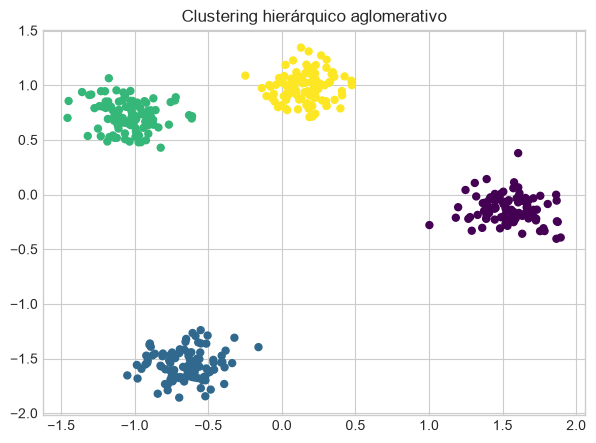

In [6]:
hierarquico = AgglomerativeClustering(n_clusters=4, linkage="ward")
labels_hierarquico = hierarquico.fit_predict(X_blobs)

plt.figure(figsize=(7, 5))
plt.scatter(X_blobs[:, 0], X_blobs[:, 1], c=labels_hierarquico, cmap="viridis", s=25)
plt.title("Clustering hierárquico aglomerativo")
plt.show()

## 4. DBSCAN: clusters definidos por densidade

O DBSCAN forma grupos a partir de regiões densas e trata pontos isolados como **ruído**. Seus principais parâmetros são:

- `eps`: raio da vizinhança de um ponto;
- `min_samples`: quantidade mínima de pontos nessa vizinhança para caracterizar uma região densa.

Ao contrário do K-Means, ele não exige informar o número de clusters e consegue encontrar formas não esféricas. Porém, sua qualidade depende bastante dos parâmetros e ele pode ter dificuldade quando os grupos possuem densidades muito diferentes. O rótulo `-1` identifica ruído.

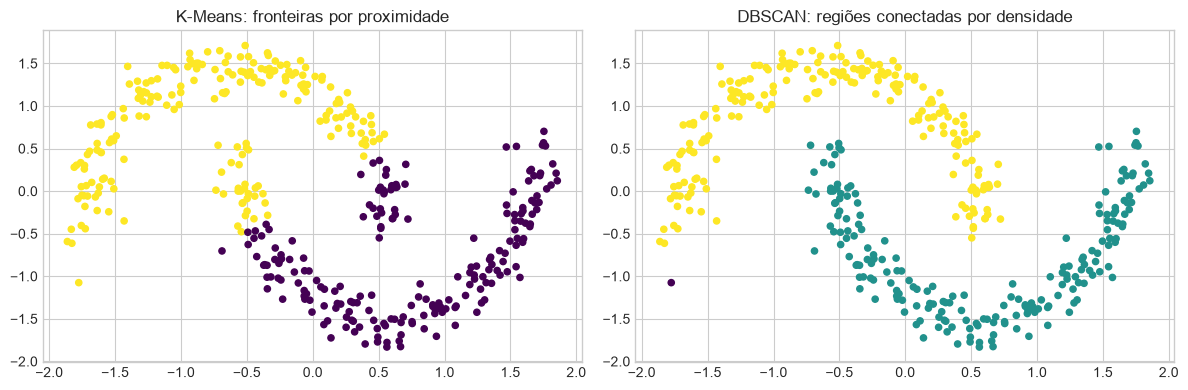

In [7]:
# As duas luas evidenciam uma situação em que clusters não são esféricos.
X_moons, _ = make_moons(n_samples=400, noise=0.08, random_state=RANDOM_STATE)
X_moons = StandardScaler().fit_transform(X_moons)

labels_moons_kmeans = KMeans(
    n_clusters=2, n_init=10, random_state=RANDOM_STATE
).fit_predict(X_moons)
labels_moons_dbscan = DBSCAN(eps=0.25, min_samples=5).fit_predict(X_moons)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].scatter(X_moons[:, 0], X_moons[:, 1], c=labels_moons_kmeans, cmap="viridis", s=20)
axes[0].set_title("K-Means: fronteiras por proximidade")
axes[1].scatter(X_moons[:, 0], X_moons[:, 1], c=labels_moons_dbscan, cmap="viridis", s=20)
axes[1].set_title("DBSCAN: regiões conectadas por densidade")
plt.tight_layout()
plt.show()

## 5. Comparação dos algoritmos

Aplicaremos os três métodos ao mesmo conjunto de dados. Essa comparação visual é útil, mas deve ser complementada por métricas e pelo significado prático dos grupos.

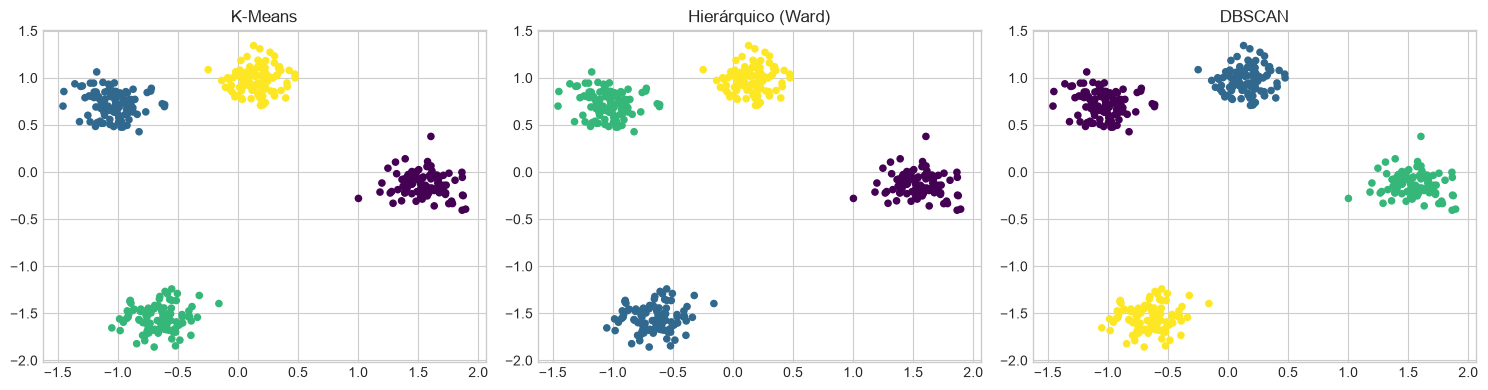

In [8]:
modelos = {
    "K-Means": KMeans(n_clusters=4, n_init=10, random_state=RANDOM_STATE),
    "Hierárquico (Ward)": AgglomerativeClustering(n_clusters=4, linkage="ward"),
    "DBSCAN": DBSCAN(eps=0.30, min_samples=5),
}

resultados = {}
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, (nome, modelo) in zip(axes, modelos.items()):
    rotulos = modelo.fit_predict(X_blobs)
    resultados[nome] = rotulos
    ax.scatter(X_blobs[:, 0], X_blobs[:, 1], c=rotulos, cmap="viridis", s=20)
    ax.set_title(nome)

plt.tight_layout()
plt.show()

### Avaliação sem rótulos verdadeiros

Duas métricas internas bastante usadas são:

- **Silhueta:** quanto maior, melhor (intervalo de -1 a 1);
- **Davies-Bouldin:** quanto menor, melhor (valor mínimo 0).

As métricas favorecem certas geometrias e não devem ser interpretadas isoladamente. No DBSCAN, removemos os pontos de ruído antes do cálculo e só calculamos as métricas se restarem pelo menos dois clusters.

In [9]:
for nome, rotulos in resultados.items():
    # No DBSCAN, -1 representa ruído e não um cluster propriamente dito.
    mascara = rotulos != -1
    X_avaliacao = X_blobs[mascara]
    labels_avaliacao = rotulos[mascara]
    numero_clusters = len(np.unique(labels_avaliacao))

    if numero_clusters >= 2:
        silhueta = silhouette_score(X_avaliacao, labels_avaliacao)
        davies_bouldin = davies_bouldin_score(X_avaliacao, labels_avaliacao)
        print(f"{nome:20s} | clusters: {numero_clusters} | silhueta: {silhueta:.3f} | DB: {davies_bouldin:.3f}")
    else:
        print(f"{nome:20s} | não foi possível calcular as métricas")

K-Means              | clusters: 4 | silhueta: 0.830 | DB: 0.236
Hierárquico (Ward)   | clusters: 4 | silhueta: 0.830 | DB: 0.236
DBSCAN               | clusters: 4 | silhueta: 0.830 | DB: 0.236


## 6. Complexidade computacional

Para comparar o custo dos algoritmos, considere:

- $n$: número de observações;
- $d$: número de atributos;
- $k$: número de clusters;
- $i$: número de iterações até a convergência;
- $r$: número de inicializações do K-Means (`n_init`).

| Algoritmo | Tempo (ordem aproximada) | Memória | Consequência prática |
|---|---|---|---|
| K-Means | $O(r \cdot n \cdot k \cdot d \cdot i)$ | $O(n \cdot d + k \cdot d)$ | Geralmente é a opção mais escalável, mas custa mais quando aumentamos $k$, `n_init` ou o número de iterações |
| Hierárquico aglomerativo | tipicamente $O(n^2 \log n)$; algumas implementações chegam a $O(n^3)$ | frequentemente $O(n^2)$ | O crescimento quadrático limita sua aplicação direta em conjuntos muito grandes |
| DBSCAN | em média $O(n \log n)$ com índice espacial; pior caso $O(n^2)$ | de $O(n)$ até $O(n^2)$ | É eficiente em baixa dimensão, mas pode degradar quando as buscas por vizinhos retornam muitos pontos |

> As ordens são referências assintóticas, não tempos exatos. Implementação, hardware, parâmetros e distribuição dos dados também influenciam o desempenho.

### Como os dados afetam a velocidade?

1. **Mais observações ($n$):** aumenta o trabalho de todos os métodos. O impacto é especialmente forte no hierárquico, pois ele precisa manter e atualizar muitas relações entre pares de pontos.
2. **Mais atributos ($d$):** cada cálculo de distância fica mais caro. Além disso, na chamada *maldição da dimensionalidade*, as distâncias tendem a ficar menos informativas e índices de vizinhança usados pelo DBSCAN perdem eficiência.
3. **Escalas diferentes:** não aumentam necessariamente o tempo, mas podem distorcer as distâncias, produzir clusters ruins e fazer o K-Means precisar de mais iterações. Por isso padronizamos os atributos.
4. **Sobreposição e formato dos grupos:** clusters bem separados costumam facilitar a convergência do K-Means. Formas alongadas ou sobrepostas podem exigir mais iterações e ainda produzir uma solução inadequada.
5. **Densidade e `eps` no DBSCAN:** um `eps` muito grande cria vizinhanças enormes, elevando o tempo e a memória. Um valor muito pequeno faz muitas consultas, embora cada vizinhança seja menor.
6. **Ruído e outliers:** o DBSCAN foi projetado para identificá-los; no K-Means, eles podem deslocar centroides e atrasar a estabilização.

Assim, o tamanho do arquivo não é o único fator: duas bases com o mesmo número de linhas podem ter tempos bastante diferentes por causa da dimensionalidade e da distribuição dos pontos.

### Experimento: crescimento do tempo com o número de observações

O experimento abaixo mede o tempo de ajuste nos mesmos dados, variando apenas $n$. Os valores dependem da máquina e podem oscilar; o mais importante é observar a **tendência de crescimento**, não comparar diferenças de poucos milissegundos.

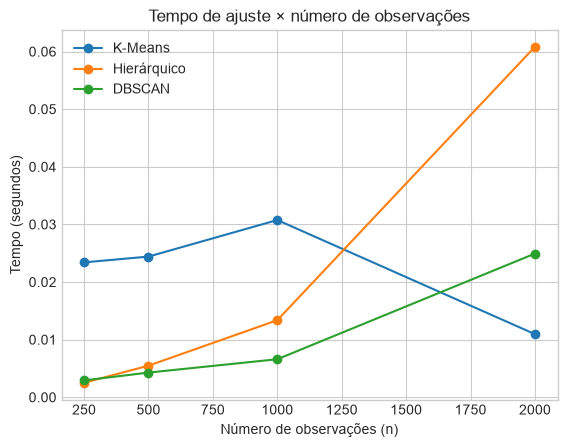

In [10]:
from time import perf_counter

tamanhos = [250, 500, 1000, 2000]
tempos = {"K-Means": [], "Hierárquico": [], "DBSCAN": []}

for n_amostras in tamanhos:
    X_tempo, _ = make_blobs(
        n_samples=n_amostras, centers=4, n_features=2,
        cluster_std=0.85, random_state=RANDOM_STATE
    )
    X_tempo = StandardScaler().fit_transform(X_tempo)

    # Usamos os mesmos dados para tornar a comparação mais justa.
    modelos_tempo = {
        "K-Means": KMeans(n_clusters=4, n_init=10, random_state=RANDOM_STATE),
        "Hierárquico": AgglomerativeClustering(n_clusters=4, linkage="ward"),
        "DBSCAN": DBSCAN(eps=0.30, min_samples=5),
    }

    for nome, modelo in modelos_tempo.items():
        inicio = perf_counter()
        modelo.fit(X_tempo)
        tempos[nome].append(perf_counter() - inicio)

for nome, valores in tempos.items():
    plt.plot(tamanhos, valores, marker="o", label=nome)

plt.title("Tempo de ajuste × número de observações")
plt.xlabel("Número de observações (n)")
plt.ylabel("Tempo (segundos)")
plt.legend()
plt.show()

### Estratégias para conjuntos maiores

- Preferir **MiniBatchKMeans** quando o K-Means tradicional ficar lento.
- Reduzir atributos redundantes, selecionando variáveis ou usando PCA quando fizer sentido.
- Ajustar `eps` e `min_samples` do DBSCAN com amostragem antes de processar toda a base.
- Aplicar clustering hierárquico em uma amostra ou nos centroides produzidos por um método mais escalável.
- Medir tempo e memória com dados representativos: a complexidade teórica indica a tendência, mas o teste real revela o custo no ambiente de uso.

## 7. Síntese

| Algoritmo | Principal vantagem | Principal limitação | Quando considerar |
|---|---|---|---|
| K-Means | Simples, rápido e escalável | Exige $k$ e prefere grupos esféricos | Muitos dados e clusters compactos |
| Hierárquico | Revela relações em vários níveis | Custo cresce rapidamente com o volume | Exploração e interpretação da hierarquia |
| DBSCAN | Encontra formas arbitrárias e identifica ruído | Sensível a `eps` e a variações de densidade | Dados espaciais, ruído e formas irregulares |

### Mensagens principais

1. Não existe um algoritmo universalmente melhor: a geometria e o objetivo do problema importam.
2. Como os métodos dependem de distância ou densidade, a escala das variáveis precisa ser considerada.
3. Visualizações e métricas ajudam, mas a utilidade dos clusters deve ser validada no contexto da aplicação.